# EDA Datathon

## Importação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/bank-additional-full.csv',sep=';')

print(df.shape)
df.info()
df["y"].value_counts(normalize=True)

(41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

## Transformação

In [3]:
# duration deletada pois não usamos pro treinamento, feature só existe pós ligação

df_tratado = df.drop(columns=['duration'])
df_tratado

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
(df == "unknown").mean()

age               0.000000
job               0.008012
marital           0.001942
education         0.042027
default           0.208726
housing           0.024036
loan              0.024036
contact           0.000000
month             0.000000
day_of_week       0.000000
duration          0.000000
campaign          0.000000
pdays             0.000000
previous          0.000000
poutcome          0.000000
emp.var.rate      0.000000
cons.price.idx    0.000000
cons.conf.idx     0.000000
euribor3m         0.000000
nr.employed       0.000000
y                 0.000000
dtype: float64

In [5]:
# não uso default pra segmentação nem pra API (personalização responsável / minimização de dados)
# ~21% de unknown reforça essa decisão
df = df.drop(columns=["default"])

## Gráficos

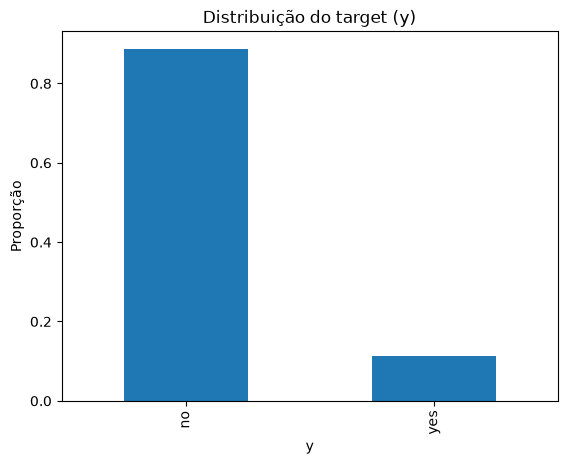

In [6]:
df["y"].value_counts(normalize=True).plot(kind="bar")
plt.title("Distribuição do target (y)")
plt.ylabel("Proporção")
plt.show()

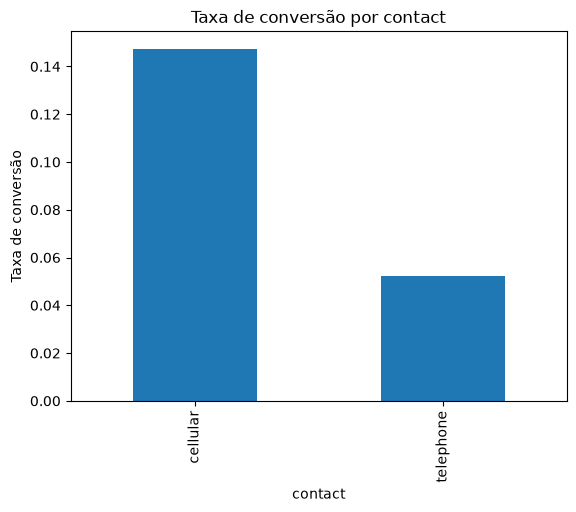

In [7]:
df.groupby("contact")["y"].apply(lambda x: (x == "yes").mean()).plot(kind="bar")
plt.title("Taxa de conversão por contact")
plt.ylabel("Taxa de conversão")
plt.show()

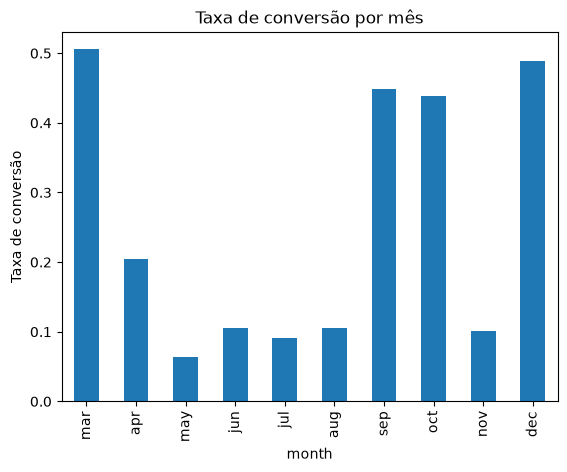

In [8]:
ordem_meses = ["mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

conversao_mes = df.groupby("month")["y"].apply(lambda x: (x == "yes").mean())
conversao_mes = conversao_mes.reindex(ordem_meses)
conversao_mes.plot(kind="bar")
plt.title("Taxa de conversão por mês")
plt.ylabel("Taxa de conversão")
plt.show()

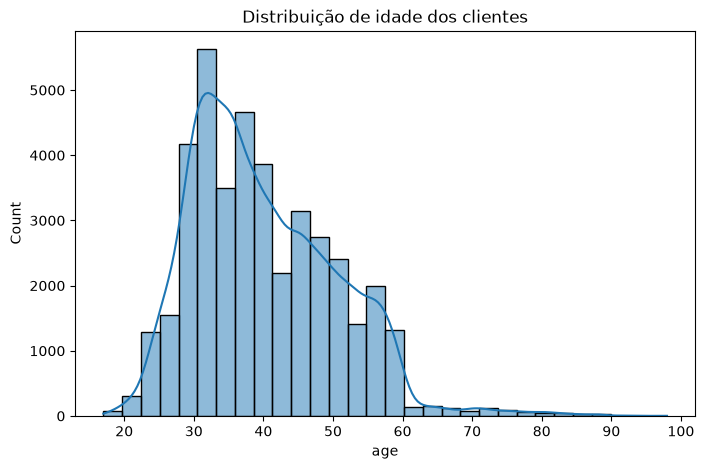

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribuição de idade dos clientes")
plt.show()

df["age"].describe()

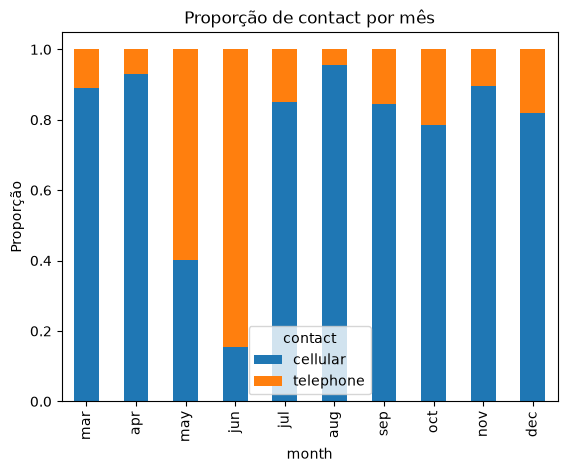

In [10]:
tab = pd.crosstab(df["month"], df["contact"], normalize="index")
tab = tab.reindex(ordem_meses)
tab.plot(kind="bar", stacked=True)
plt.title("Proporção de contact por mês")
plt.ylabel("Proporção")
plt.show()

In [11]:
df["braco"] = df["contact"] + "_" + df["day_of_week"]
df["braco"].value_counts()

braco
cellular_thu     5805
cellular_mon     5535
cellular_tue     5107
cellular_wed     5052
cellular_fri     4645
telephone_fri    3182
telephone_wed    3082
telephone_tue    2983
telephone_mon    2979
telephone_thu    2818
Name: count, dtype: int64

In [12]:
df["y_flag"] = (df["y"] == "yes").astype(int)

tabela_bracos = df.groupby("braco")["y_flag"].agg(["mean", "count"]).sort_values("count", ascending=False)
print(tabela_bracos)

print(tabela_bracos.sort_values("mean", ascending=False))

                   mean  count
braco                         
cellular_thu   0.153661   5805
cellular_mon   0.127913   5535
cellular_tue   0.157627   5107
cellular_wed   0.152811   5052
cellular_fri   0.145533   4645
telephone_fri  0.053426   3182
telephone_wed  0.057430   3082
telephone_tue  0.049614   2983
telephone_mon  0.046660   2979
telephone_thu  0.054294   2818
                   mean  count
braco                         
cellular_tue   0.157627   5107
cellular_thu   0.153661   5805
cellular_wed   0.152811   5052
cellular_fri   0.145533   4645
cellular_mon   0.127913   5535
telephone_wed  0.057430   3082
telephone_thu  0.054294   2818
telephone_fri  0.053426   3182
telephone_tue  0.049614   2983
telephone_mon  0.046660   2979


In [13]:
df["tercil_idade"], cortes = pd.qcut(df["age"], 3, labels=["jovem", "meio", "senior"], retbins=True)
print("cortes:", cortes)

conversao_seg = df.groupby(["tercil_idade", "braco"])["y_flag"].mean().unstack()
print(conversao_seg)
print(conversao_seg.idxmax(axis=1))

contagem_seg = df.groupby(["tercil_idade", "braco"]).size().unstack()
print(contagem_seg)

cortes: [17. 34. 44. 98.]
braco         cellular_fri  cellular_mon  cellular_thu  cellular_tue  \
tercil_idade                                                           
jovem             0.172074      0.144585      0.155844      0.189619   
meio              0.119435      0.101918      0.132466      0.104536   
senior            0.139628      0.136615      0.171395      0.169611   

braco         cellular_wed  telephone_fri  telephone_mon  telephone_thu  \
tercil_idade                                                              
jovem             0.163743       0.054956       0.045005       0.066590   
meio              0.115942       0.048511       0.042934       0.047259   
senior            0.175439       0.057692       0.052632       0.050619   

braco         telephone_tue  telephone_wed  
tercil_idade                                
jovem              0.066519       0.062956  
meio               0.039377       0.051518  
senior             0.045501       0.057842  
tercil_idade

In [14]:
df.to_parquet("../data/base_tratada.parquet")

A base tem 41.188 registros de uma campanha de telemarketing de um banco, com ~11% de conversão (y = yes). Dropei duration porque só é conhecida depois da ligação acontecer, usá-la seria vazamento temporal. Também dropei default, além de ~21% dos valores virem como "unknown", essa variável não entra em nenhuma decisão do modelo (nem segmentação, nem API), por decisão de personalização responsável.

Defini o "braço" do bandit como a combinação de contact (canal) e day_of_week (dia), totalizando 10 combinações possíveis. 

O gráfico de contact × month mostra que contact não é uma escolha livre do banco: a campanha migrou de telephone para cellular ao longo do tempo. Ou seja, o braço "descoberto" pelo bandit está em parte medindo período da campanha, não só canal.

Para segmentar, usei tercil de idade (cortes em 34 e 44 anos) em vez de poutcome, porque a categoria success de poutcome tem poucas linhas — viraria ruído no bandit.

---